# Datathon Passos Mágicos — Notebook 02: Análise Exploratória

**Objetivo:** Responder as 11 perguntas analíticas do datathon usando os dados PEDE 2022–2024.

**Dataset:** `data/pede_consolidado.csv` — 3.030 registros, 3 anos

---
### Indicadores analisados
| Sigla | Significado |
|-------|-------------|
| **INDE** | Índice de Desenvolvimento Educacional (nota global) |
| **IAN** | Índice de Adequação do Nível (defasagem) |
| **IDA** | Índice de Desempenho Acadêmico |
| **IEG** | Índice de Engajamento |
| **IAA** | Índice de Autoavaliação |
| **IPS** | Índice Psicossocial |
| **IPP** | Índice Psicopedagógico |
| **IPV** | Índice do Ponto de Virada |


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Paletas
CORES_ANO  = {2022: '#4C72B0', 2023: '#E87B3B', 2024: '#5B9E6E'}
CORES_PEDRA = {
    'QUARTZO' : '#A8D5E2',
    'AGATA'   : '#B5D5A0',
    'AMETISTA': '#C9A8E0',
    'TOPAZIO' : '#F6D860'
}
ORDEM_PEDRA = ['QUARTZO', 'AGATA', 'AMETISTA', 'TOPAZIO']
INDICADORES = ['INDE', 'IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']

# Caminhos
BASE = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH = os.path.join(BASE, '..', 'data')

df = pd.read_csv(os.path.join(DATA_PATH, 'pede_consolidado.csv'))
print(f'Dataset: {df.shape[0]:,} registros x {df.shape[1]} colunas')
print(f'Anos: {sorted(df["ANO"].unique())}')
print(f'Alunos únicos: {df["RA"].nunique():,}')
df[['ANO', 'Fase', 'Pedra'] + INDICADORES].head(3)

Dataset: 3,030 registros x 64 colunas
Anos: [np.int64(2022), np.int64(2023), np.int64(2024)]
Alunos únicos: 1,661


,ANO,Fase,Pedra,INDE,IAA,IEG,IPS,IDA,IPP,IPV,IAN
0,2022,7,QUARTZO,5.783,8.300,4.100,5.600,4.000,NaN,7.278,5.000
1,2022,7,AMETISTA,7.055,8.800,5.200,6.300,6.800,NaN,6.778,10.000
2,2022,7,AGATA,6.591,0.000,7.900,5.600,5.600,NaN,7.556,10.000


---
## Pergunta 1 — Adequação do Nível (IAN)
> *Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano?*

**IAN assume 3 valores:**
- **2,5** → Severamente defasado (≥2 fases abaixo)
- **5,0** → Moderadamente defasado (1 fase abaixo)
- **10,0** → Adequado (na fase ideal)

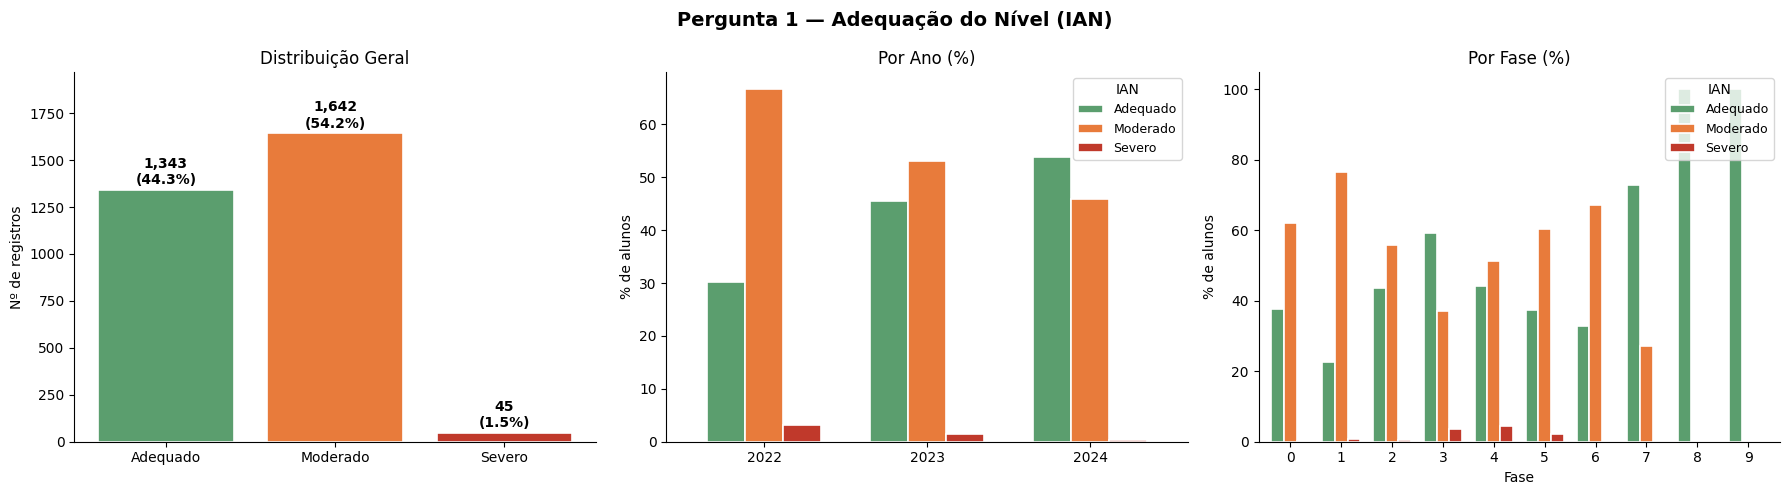


📊 INSIGHT:
  Adequados:    44.3%
  Moderados:    54.2%
  Severos:      1.5%
  Total em defasagem: 55.7%


In [29]:
# Mapeia IAN para rótulos legíveis
df['IAN_Cat'] = df['IAN'].map({2.5: 'Severo', 5.0: 'Moderado', 10.0: 'Adequado'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pergunta 1 — Adequação do Nível (IAN)', fontsize=14, fontweight='bold')

# 1a — Distribuição geral
ax = axes[0]
dist = df['IAN_Cat'].value_counts()[['Adequado', 'Moderado', 'Severo']]
cores = ['#5B9E6E', '#E87B3B', '#C0392B']
bars = ax.bar(dist.index, dist.values, color=cores, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, dist.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Distribuição Geral', fontsize=12)
ax.set_ylabel('Nº de registros')
ax.set_ylim(0, dist.max() * 1.2)
ax.spines[['top','right']].set_visible(False)

# 1b — Por ano
ax = axes[1]
ordem = ['Adequado', 'Moderado', 'Severo']
ian_ano = df.groupby(['ANO', 'IAN_Cat']).size().unstack(fill_value=0)[ordem]
ian_ano_pct = ian_ano.div(ian_ano.sum(axis=1), axis=0) * 100
ian_ano_pct.plot(kind='bar', ax=ax, color=['#5B9E6E', '#E87B3B', '#C0392B'],
                 edgecolor='white', linewidth=1.2, width=0.7)
ax.set_title('Por Ano (%)', fontsize=12)
ax.set_ylabel('% de alunos')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='IAN', loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)

# 1c — Por fase
ax = axes[2]
ian_fase = df.groupby(['Fase', 'IAN_Cat']).size().unstack(fill_value=0)
for col in ordem:
    if col not in ian_fase.columns:
        ian_fase[col] = 0
ian_fase = ian_fase[ordem]
ian_fase_pct = ian_fase.div(ian_fase.sum(axis=1), axis=0) * 100
ian_fase_pct.plot(kind='bar', ax=ax, color=['#5B9E6E', '#E87B3B', '#C0392B'],
                  edgecolor='white', linewidth=1.2, width=0.75)
ax.set_title('Por Fase (%)', fontsize=12)
ax.set_ylabel('% de alunos')
ax.set_xlabel('Fase')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='IAN', loc='upper right', fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p1_ian_perfil.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 INSIGHT:')
adequado_pct = (df['IAN'] == 10.0).mean() * 100
moderado_pct = (df['IAN'] == 5.0).mean() * 100
severo_pct   = (df['IAN'] == 2.5).mean() * 100
print(f'  Adequados:    {adequado_pct:.1f}%')
print(f'  Moderados:    {moderado_pct:.1f}%')
print(f'  Severos:      {severo_pct:.1f}%')
print(f'  Total em defasagem: {moderado_pct + severo_pct:.1f}%')

---
## Pergunta 2 — Desempenho Acadêmico (IDA)
> *O IDA está melhorando, estagnado ou caindo ao longo das fases e anos?*

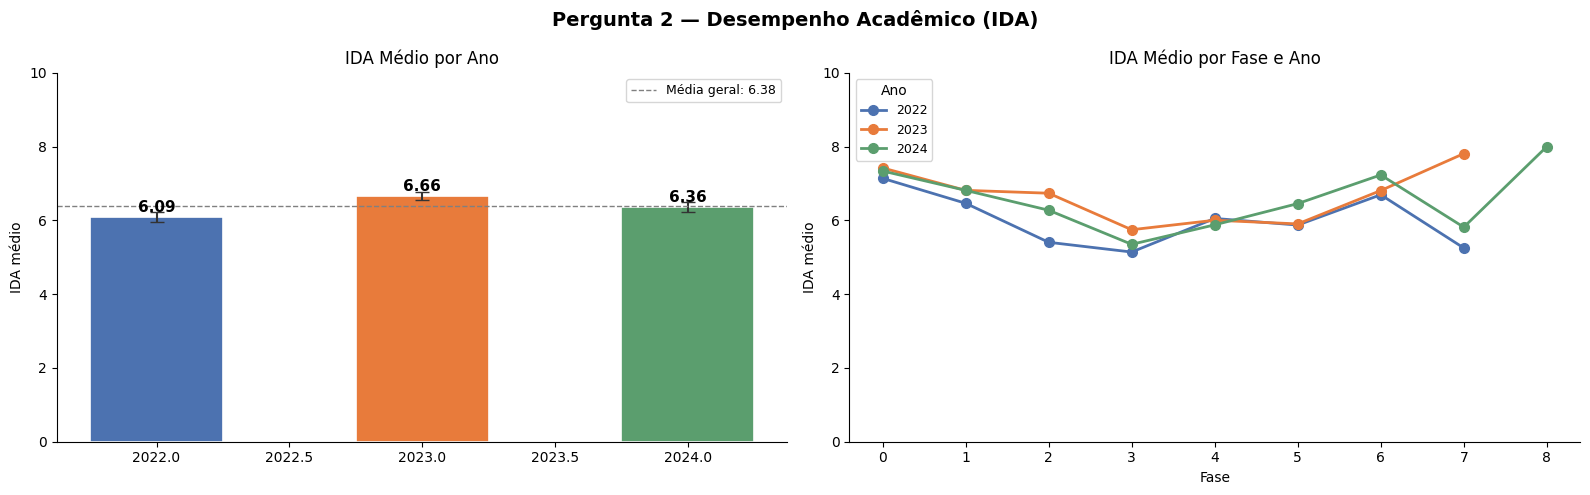


📊 IDA médio por ano:
ANO
2022   6.093
2023   6.663
2024   6.365
Name: IDA, dtype: float64

📊 IDA médio por fase:
Fase
0   7.309
1   6.692
2   6.196
3   5.395
4   5.967
5   6.141
6   6.921
7   5.935
8   8.000
9     NaN
Name: IDA, dtype: float64


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Pergunta 2 — Desempenho Acadêmico (IDA)', fontsize=14, fontweight='bold')

# 2a — IDA médio por ano
ax = axes[0]
ida_ano = df.groupby('ANO')['IDA'].agg(['mean', 'std', 'count'])
anos = ida_ano.index.tolist()
medias = ida_ano['mean'].values
erros  = ida_ano['std'].values / np.sqrt(ida_ano['count'].values)
cores = [CORES_ANO[a] for a in anos]
bars = ax.bar(anos, medias, color=cores, edgecolor='white', linewidth=1.2, width=0.5)
ax.errorbar(anos, medias, yerr=erros*1.96, fmt='none', color='#333', capsize=5, linewidth=1.5)
for bar, m in zip(bars, medias):
    ax.text(bar.get_x() + bar.get_width()/2, m + 0.05,
            f'{m:.2f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title('IDA Médio por Ano', fontsize=12)
ax.set_ylabel('IDA médio')
ax.set_ylim(0, 10)
ax.axhline(df['IDA'].mean(), color='grey', linestyle='--', linewidth=1, label=f'Média geral: {df["IDA"].mean():.2f}')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# 2b — IDA médio por fase e ano
ax = axes[1]
for ano, cor in CORES_ANO.items():
    sub = df[df['ANO'] == ano].groupby('Fase')['IDA'].mean()
    ax.plot(sub.index, sub.values, marker='o', color=cor, label=str(ano), linewidth=2, markersize=7)
ax.set_title('IDA Médio por Fase e Ano', fontsize=12)
ax.set_xlabel('Fase')
ax.set_ylabel('IDA médio')
ax.legend(title='Ano', fontsize=9)
ax.set_ylim(0, 10)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p2_ida_tendencia.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 IDA médio por ano:')
print(df.groupby('ANO')['IDA'].mean().round(3))
print('\n📊 IDA médio por fase:')
print(df.groupby('Fase')['IDA'].mean().round(3))

---
## Pergunta 3 — Engajamento x Desempenho e Ponto de Virada (IEG × IDA × IPV)
> *O engajamento (IEG) tem relação direta com IDA e IPV?*

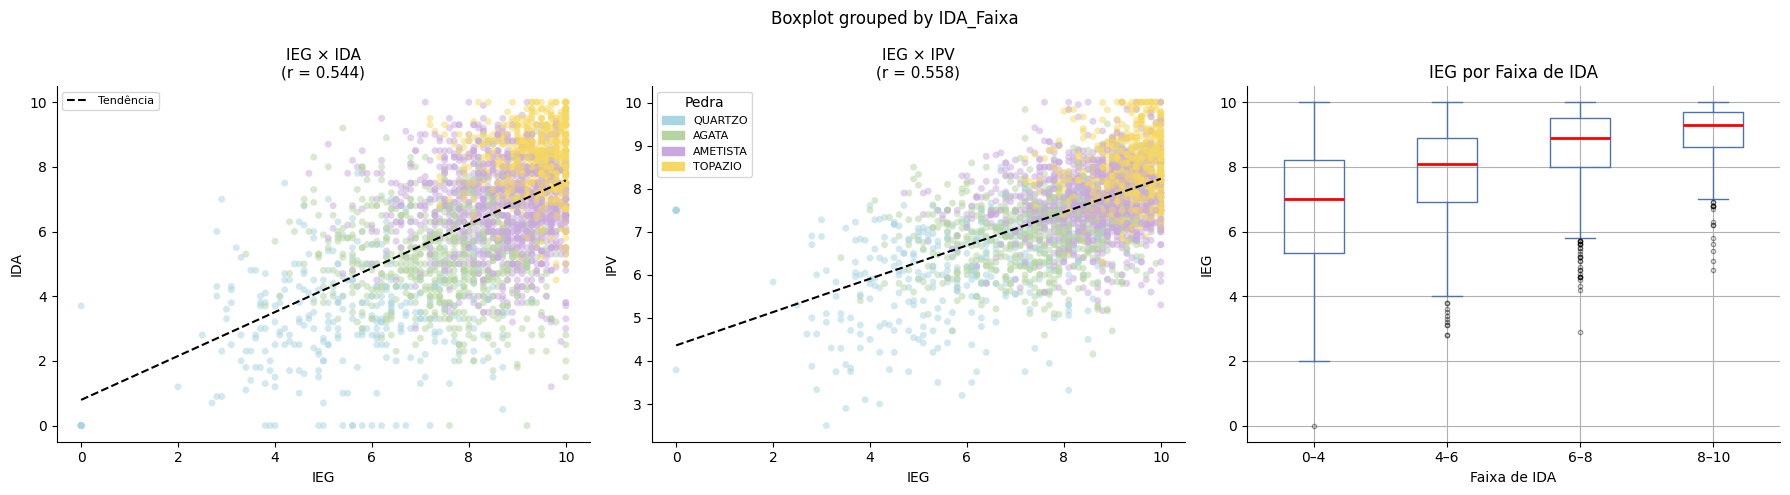


📊 Matriz de correlação IEG × IDA × IPV:
      IEG   IDA   IPV
IEG 1.000 0.539 0.558
IDA 0.539 1.000 0.556
IPV 0.558 0.556 1.000


In [31]:
sub = df[['IEG', 'IDA', 'IPV', 'Pedra']].dropna()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pergunta 3 — Engajamento (IEG) × Desempenho (IDA) × Ponto de Virada (IPV)', fontsize=13, fontweight='bold')

def scatter_cor(ax, x_col, y_col, data, title):
    cores_p = [CORES_PEDRA.get(p, '#999') for p in data['Pedra']]
    ax.scatter(data[x_col], data[y_col], c=cores_p, alpha=0.5, s=25, edgecolors='none')
    # linha de tendência
    z = np.polyfit(data[x_col].dropna(), data[y_col].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, label='Tendência')
    corr = data[[x_col, y_col]].corr().iloc[0, 1]
    ax.set_title(f'{title}\n(r = {corr:.3f})', fontsize=11)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.legend(fontsize=8)
    ax.spines[['top','right']].set_visible(False)
    return corr

scatter_cor(axes[0], 'IEG', 'IDA', sub, 'IEG × IDA')
scatter_cor(axes[1], 'IEG', 'IPV', sub, 'IEG × IPV')

# Legenda de pedras
patches = [mpatches.Patch(color=v, label=k) for k, v in CORES_PEDRA.items()]
axes[1].legend(handles=patches, title='Pedra', fontsize=8, loc='upper left')

# Boxplot IEG por faixa de IDA
ax = axes[2]
sub2 = sub.copy()
sub2['IDA_Faixa'] = pd.cut(sub2['IDA'], bins=[0,4,6,8,10], labels=['0–4','4–6','6–8','8–10'])
sub2.boxplot(column='IEG', by='IDA_Faixa', ax=ax,
             boxprops=dict(color='#4C72B0'), medianprops=dict(color='red', linewidth=2),
             whiskerprops=dict(color='#4C72B0'), capprops=dict(color='#4C72B0'),
             flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_title('IEG por Faixa de IDA', fontsize=11)
ax.set_xlabel('Faixa de IDA')
ax.set_ylabel('IEG')
plt.sca(ax)
plt.title('IEG por Faixa de IDA')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p3_ieg_correlacao.png'), dpi=150, bbox_inches='tight')
plt.show()

corr_matrix = df[['IEG','IDA','IPV']].corr().round(3)
print('\n📊 Matriz de correlação IEG × IDA × IPV:')
print(corr_matrix)

---
## Pergunta 4 — Autoavaliação (IAA) × Desempenho Real (IDA) e Engajamento (IEG)
> *As percepções dos alunos sobre si mesmos (IAA) são coerentes com IDA e IEG?*

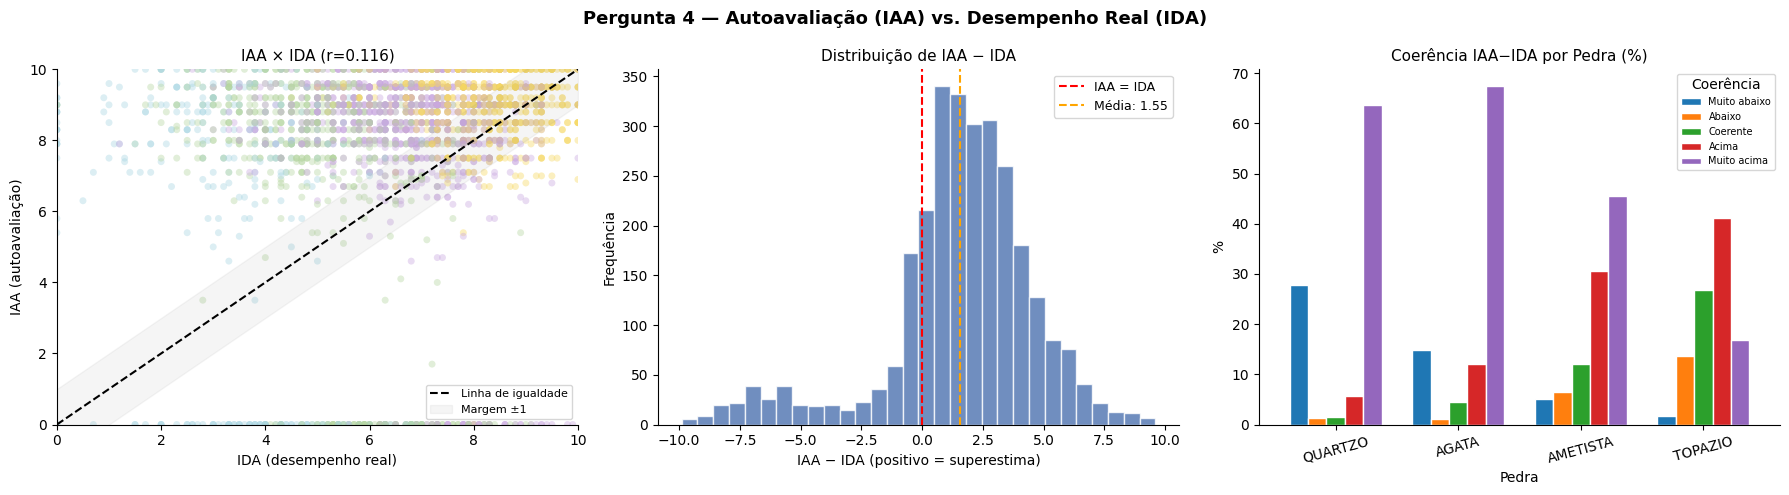


📊 % por categoria de coerência:
Coerencia
Muito acima    46.200
Acima          25.700
Coerente       12.600
Muito abaixo    9.300
Abaixo          6.300
Name: proportion, dtype: float64

  Superestimam (IAA > IDA +0.5): 71.8%
  Coerentes (±0.5):              13.6%
  Subestimam (IAA < IDA -0.5):   14.6%


In [32]:
sub = df[['IAA', 'IDA', 'IEG', 'Pedra']].dropna()

# Diferença: IAA - IDA (superestimação = positivo)
sub['Delta_IAA_IDA'] = sub['IAA'] - sub['IDA']
sub['Coerencia'] = pd.cut(sub['Delta_IAA_IDA'],
                          bins=[-np.inf, -2, -0.5, 0.5, 2, np.inf],
                          labels=['Muito abaixo', 'Abaixo', 'Coerente', 'Acima', 'Muito acima'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pergunta 4 — Autoavaliação (IAA) vs. Desempenho Real (IDA)', fontsize=13, fontweight='bold')

# 4a — Scatter IAA vs IDA
ax = axes[0]
cores_p = [CORES_PEDRA.get(p, '#999') for p in sub['Pedra']]
ax.scatter(sub['IDA'], sub['IAA'], c=cores_p, alpha=0.4, s=25, edgecolors='none')
lims = [0, 10]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Linha de igualdade')
ax.fill_between(lims, [l-1 for l in lims], [l+1 for l in lims], alpha=0.08, color='grey', label='Margem ±1')
corr = sub[['IDA','IAA']].corr().iloc[0,1]
ax.set_title(f'IAA × IDA (r={corr:.3f})', fontsize=11)
ax.set_xlabel('IDA (desempenho real)')
ax.set_ylabel('IAA (autoavaliação)')
ax.legend(fontsize=8)
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.spines[['top','right']].set_visible(False)

# 4b — Distribuição do delta
ax = axes[1]
ax.hist(sub['Delta_IAA_IDA'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='IAA = IDA')
ax.axvline(sub['Delta_IAA_IDA'].mean(), color='orange', linestyle='--', linewidth=1.5,
           label=f'Média: {sub["Delta_IAA_IDA"].mean():.2f}')
ax.set_title('Distribuição de IAA − IDA', fontsize=11)
ax.set_xlabel('IAA − IDA (positivo = superestima)')
ax.set_ylabel('Frequência')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# 4c — Coerência por Pedra
ax = axes[2]
coerc_pedra = sub.groupby(['Pedra', 'Coerencia']).size().unstack(fill_value=0)
coerc_pedra_pct = coerc_pedra.div(coerc_pedra.sum(axis=1), axis=0) * 100
for p in ORDEM_PEDRA:
    if p in coerc_pedra_pct.index:
        pass
coerc_pedra_pct = coerc_pedra_pct.reindex([p for p in ORDEM_PEDRA if p in coerc_pedra_pct.index])
coerc_pedra_pct.plot(kind='bar', ax=ax, width=0.75, edgecolor='white', linewidth=1)
ax.set_title('Coerência IAA−IDA por Pedra (%)', fontsize=11)
ax.set_xlabel('Pedra')
ax.set_ylabel('%')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Coerência', fontsize=7, loc='upper right')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p4_iaa_coerencia.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 % por categoria de coerência:')
print(sub['Coerencia'].value_counts(normalize=True).mul(100).round(1))

superestima = (sub['Delta_IAA_IDA'] > 0.5).mean() * 100
subestima   = (sub['Delta_IAA_IDA'] < -0.5).mean() * 100
coerente    = ((sub['Delta_IAA_IDA'] >= -0.5) & (sub['Delta_IAA_IDA'] <= 0.5)).mean() * 100
print(f'\n  Superestimam (IAA > IDA +0.5): {superestima:.1f}%')
print(f'  Coerentes (±0.5):              {coerente:.1f}%')
print(f'  Subestimam (IAA < IDA -0.5):   {subestima:.1f}%')

---
## Pergunta 5 — Padrões Psicossociais (IPS) × Quedas de Desempenho
> *Há padrões em IPS que antecedem quedas de desempenho (IDA) ou engajamento (IEG)?*

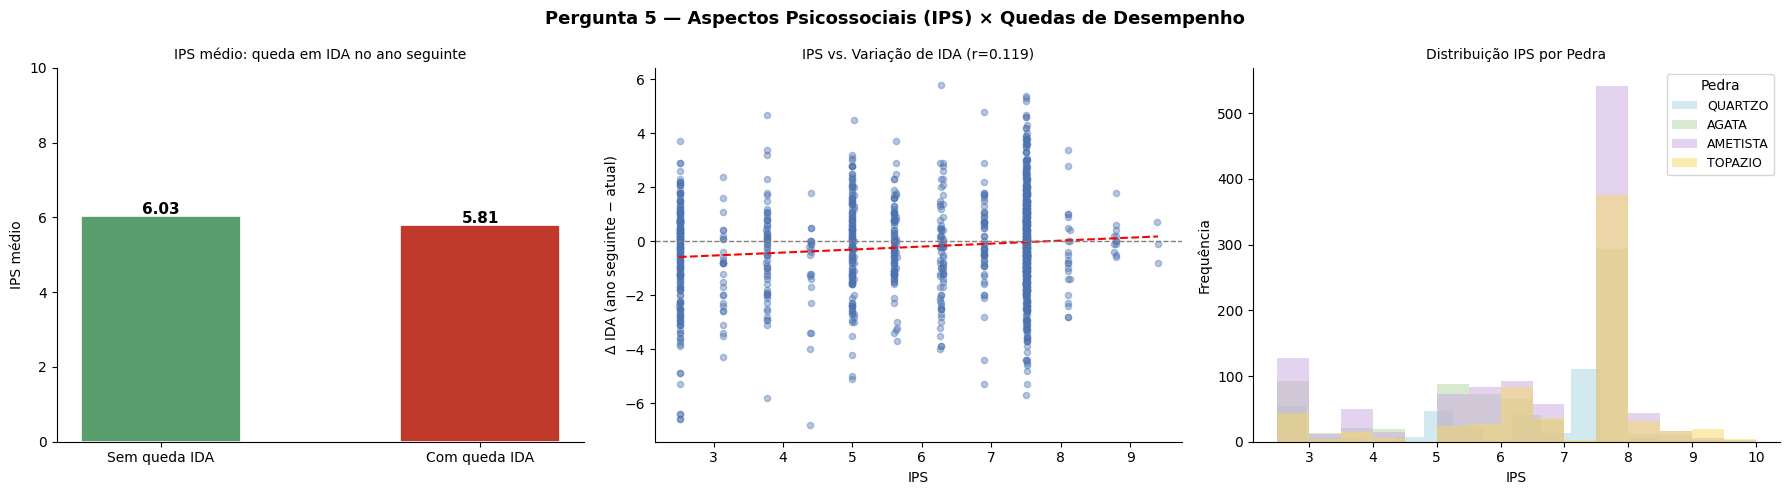


Alunos com dados em 2+ anos: 901
Registros na análise longitudinal: 1,257
% que caíram em IDA no ano seguinte: 39.9%
IPS médio quem caiu: 5.81
IPS médio quem não caiu: 6.03


In [33]:
# Análise longitudinal: alunos presentes em pelo menos 2 anos
anos_por_aluno = df.groupby('RA')['ANO'].nunique()
alunos_multi   = anos_por_aluno[anos_por_aluno >= 2].index
df_long = df[df['RA'].isin(alunos_multi)].sort_values(['RA','ANO'])

# Calcula variação inter-ano
df_long['IDA_next'] = df_long.groupby('RA')['IDA'].shift(-1)
df_long['IEG_next'] = df_long.groupby('RA')['IEG'].shift(-1)
df_long['delta_IDA'] = df_long['IDA_next'] - df_long['IDA']
df_long['delta_IEG'] = df_long['IEG_next'] - df_long['IEG']
df_long['Queda_IDA'] = df_long['delta_IDA'] < -0.5
df_long['Queda_IEG'] = df_long['delta_IEG'] < -0.5
df_valid = df_long.dropna(subset=['IPS', 'delta_IDA', 'delta_IEG'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pergunta 5 — Aspectos Psicossociais (IPS) × Quedas de Desempenho', fontsize=13, fontweight='bold')

# 5a — IPS médio: queda vs sem queda em IDA
ax = axes[0]
grupos = df_valid.groupby('Queda_IDA')['IPS'].mean()
labels = ['Sem queda IDA', 'Com queda IDA']
ax.bar(labels, [grupos.get(False, 0), grupos.get(True, 0)],
       color=['#5B9E6E', '#C0392B'], edgecolor='white', linewidth=1.2, width=0.5)
for i, (lbl, val) in enumerate(zip(labels, [grupos.get(False, 0), grupos.get(True, 0)])):
    ax.text(i, val + 0.05, f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')
ax.set_title('IPS médio: queda em IDA no ano seguinte', fontsize=10)
ax.set_ylabel('IPS médio')
ax.set_ylim(0, 10)
ax.spines[['top','right']].set_visible(False)

# 5b — Scatter IPS × delta_IDA
ax = axes[1]
ax.scatter(df_valid['IPS'], df_valid['delta_IDA'], alpha=0.4, s=20, color='#4C72B0')
z = np.polyfit(df_valid['IPS'], df_valid['delta_IDA'], 1)
p = np.poly1d(z)
x_l = np.linspace(df_valid['IPS'].min(), df_valid['IPS'].max(), 100)
ax.plot(x_l, p(x_l), 'r--', linewidth=1.5)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
corr = df_valid[['IPS','delta_IDA']].corr().iloc[0,1]
ax.set_title(f'IPS vs. Variação de IDA (r={corr:.3f})', fontsize=10)
ax.set_xlabel('IPS')
ax.set_ylabel('Δ IDA (ano seguinte − atual)')
ax.spines[['top','right']].set_visible(False)

# 5c — Distribuição de IPS por faixa de Pedra
ax = axes[2]
for pedra in ORDEM_PEDRA:
    dados = df[df['Pedra'] == pedra]['IPS'].dropna()
    if len(dados) > 0:
        ax.hist(dados, bins=15, alpha=0.5, label=pedra, color=CORES_PEDRA[pedra], edgecolor='none')
ax.set_title('Distribuição IPS por Pedra', fontsize=10)
ax.set_xlabel('IPS')
ax.set_ylabel('Frequência')
ax.legend(title='Pedra', fontsize=9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p5_ips_padroes.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\nAlunos com dados em 2+ anos: {len(alunos_multi):,}')
print(f'Registros na análise longitudinal: {len(df_valid):,}')
print(f'% que caíram em IDA no ano seguinte: {df_valid["Queda_IDA"].mean()*100:.1f}%')
print(f'IPS médio quem caiu: {df_valid[df_valid["Queda_IDA"]]["IPS"].mean():.2f}')
print(f'IPS médio quem não caiu: {df_valid[~df_valid["Queda_IDA"]]["IPS"].mean():.2f}')

---
## Pergunta 6 — Aspectos Psicopedagógicos (IPP) × Defasagem (IAN)
> *As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?*

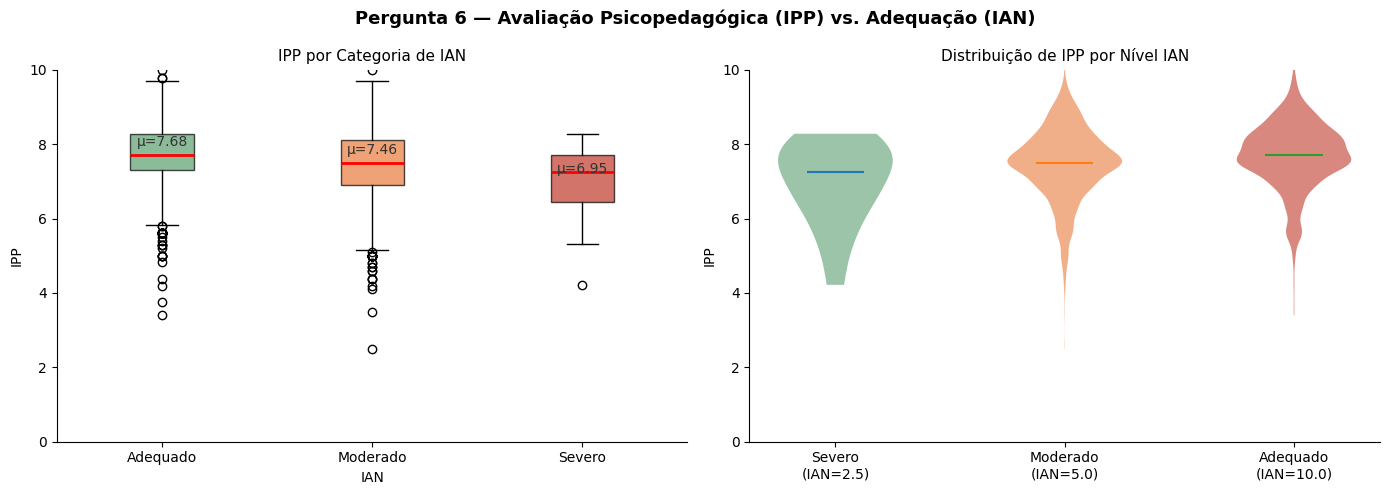


📊 IPP médio por categoria IAN:
          mean   std  count
IAN_Cat                    
Adequado 7.679 0.891    907
Moderado 7.463 0.959   1062
Severo   6.952 1.140     16

  Correlação IAN × IPP: 0.122


In [34]:
sub = df[['IPP', 'IAN', 'IAN_Cat', 'Pedra']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pergunta 6 — Avaliação Psicopedagógica (IPP) vs. Adequação (IAN)', fontsize=13, fontweight='bold')

# 6a — Boxplot IPP por categoria IAN
ax = axes[0]
ordem_cat = ['Adequado', 'Moderado', 'Severo']
dados_boxplot = [sub[sub['IAN_Cat'] == cat]['IPP'].values for cat in ordem_cat]
bp = ax.boxplot(dados_boxplot, labels=ordem_cat, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
cores_ian = ['#5B9E6E', '#E87B3B', '#C0392B']
for patch, cor in zip(bp['boxes'], cores_ian):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
ax.set_title('IPP por Categoria de IAN', fontsize=11)
ax.set_xlabel('IAN')
ax.set_ylabel('IPP')
ax.set_ylim(0, 10)
ax.spines[['top','right']].set_visible(False)

# Médias no gráfico
for i, (cat, dados) in enumerate(zip(ordem_cat, dados_boxplot), start=1):
    m = np.mean(dados)
    ax.text(i, m + 0.2, f'μ={m:.2f}', ha='center', va='bottom', fontsize=10, color='#333')

# 6b — Scatter IPP × IAN com violinplot
ax = axes[1]
positions = {2.5: 1, 5.0: 2, 10.0: 3}
for ian_val, pos in positions.items():
    dados = sub[sub['IAN'] == ian_val]['IPP'].values
    if len(dados) > 5:
        vp = ax.violinplot(dados, positions=[pos], showmedians=True, showextrema=False)
        cor = cores_ian[pos - 1]
        for pc in vp['bodies']:
            pc.set_facecolor(cor)
            pc.set_alpha(0.6)

ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Severo\n(IAN=2.5)', 'Moderado\n(IAN=5.0)', 'Adequado\n(IAN=10.0)'])
ax.set_title('Distribuição de IPP por Nível IAN', fontsize=11)
ax.set_ylabel('IPP')
ax.set_ylim(0, 10)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p6_ipp_ian.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 IPP médio por categoria IAN:')
print(sub.groupby('IAN_Cat')['IPP'].agg(['mean','std','count']).round(3))

corr = sub[['IAN','IPP']].corr().iloc[0,1]
print(f'\n  Correlação IAN × IPP: {corr:.3f}')

---
## Pergunta 7 — Ponto de Virada (IPV)
> *Quais comportamentos — acadêmicos, emocionais ou de engajamento — mais influenciam o IPV?*

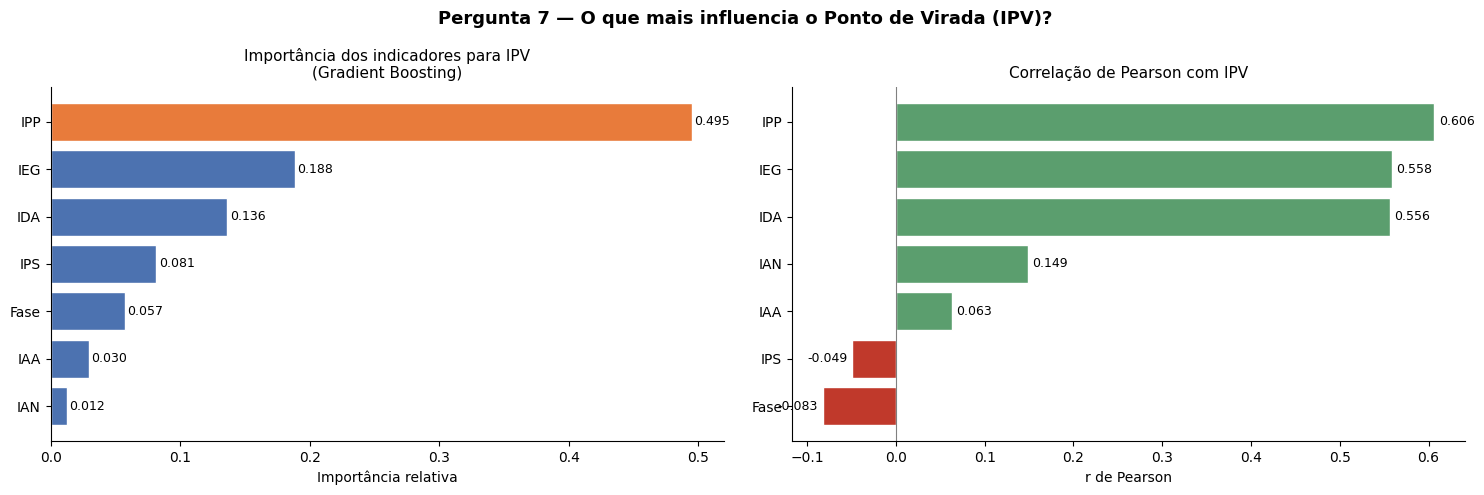


📊 Correlação de cada indicador com IPV:
Fase   -0.083
IPS    -0.049
IAA     0.063
IAN     0.149
IDA     0.556
IEG     0.558
IPP     0.606
Name: IPV, dtype: float64

  R² do modelo GBR: 0.841


In [35]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

features_ipv = ['IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IAN', 'Fase']
sub = df[features_ipv + ['IPV']].dropna()

X = sub[features_ipv]
y = sub['IPV']

gb = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
gb.fit(X, y)
importancias = pd.Series(gb.feature_importances_, index=features_ipv).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Pergunta 7 — O que mais influencia o Ponto de Virada (IPV)?', fontsize=13, fontweight='bold')

# 7a — Feature importance
ax = axes[0]
cores_imp = ['#4C72B0' if v < importancias.max() else '#E87B3B' for v in importancias.values]
bars = ax.barh(importancias.index, importancias.values, color=cores_imp, edgecolor='white')
for bar, val in zip(bars, importancias.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)
ax.set_title('Importância dos indicadores para IPV\n(Gradient Boosting)', fontsize=11)
ax.set_xlabel('Importância relativa')
ax.spines[['top','right']].set_visible(False)

# 7b — Correlações com IPV
ax = axes[1]
corrs = df[features_ipv + ['IPV']].corr()['IPV'].drop('IPV').sort_values()
cores_corr = ['#C0392B' if v < 0 else '#5B9E6E' for v in corrs.values]
bars2 = ax.barh(corrs.index, corrs.values, color=cores_corr, edgecolor='white')
ax.axvline(0, color='grey', linewidth=0.8)
for bar, val in zip(bars2, corrs.values):
    offset = 0.005 if val >= 0 else -0.005
    ax.text(val + offset, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)
ax.set_title('Correlação de Pearson com IPV', fontsize=11)
ax.set_xlabel('r de Pearson')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p7_ipv_drivers.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Correlação de cada indicador com IPV:')
print(corrs.round(4))
print(f'\n  R² do modelo GBR: {gb.score(X, y):.3f}')

---
## Pergunta 8 — Multidimensionalidade: combinações que elevam o INDE
> *Quais combinações de IDA + IEG + IPS + IPP elevam mais a nota global (INDE)?*

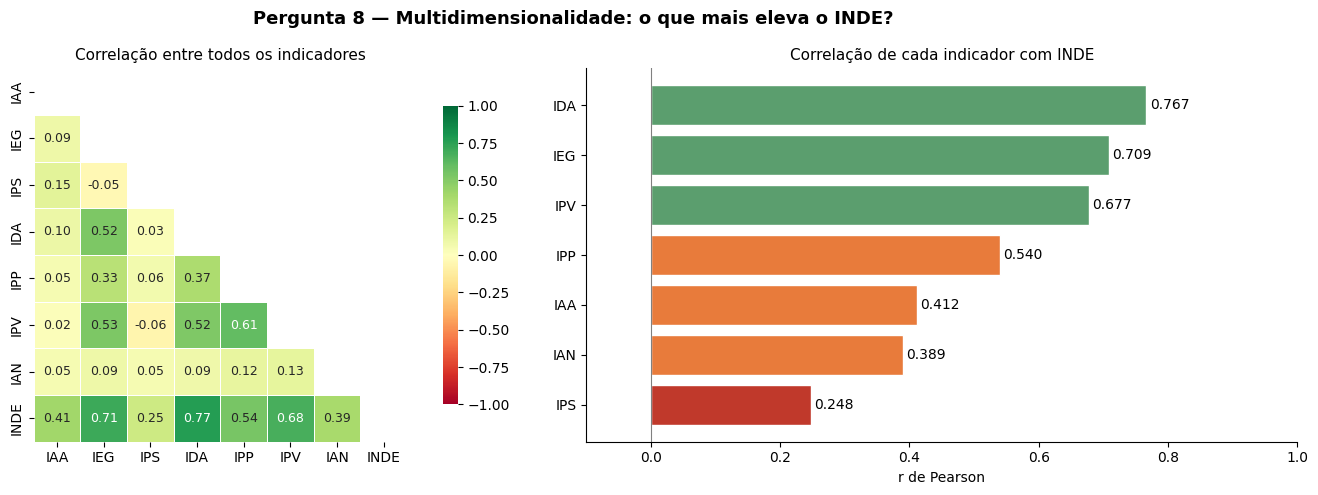


📊 Correlação com INDE (ordenada):
IPS   0.248
IAN   0.390
IAA   0.412
IPP   0.540
IPV   0.677
IEG   0.709
IDA   0.767
Name: INDE, dtype: float64

📊 Coeficientes (regressão linear padronizada) → impacto no INDE:
IDA   0.380
IEG   0.303
IAA   0.281
IAN   0.253
IPV   0.211
IPS   0.196
IPP   0.094
dtype: float64
  R² = 1.000


In [36]:
inds = ['IAA', 'IEG', 'IPS', 'IDA', 'IPP', 'IPV', 'IAN']
sub = df[inds + ['INDE']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Pergunta 8 — Multidimensionalidade: o que mais eleva o INDE?', fontsize=13, fontweight='bold')

# 8a — Heatmap de correlação
ax = axes[0]
corr = sub.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
ax.set_title('Correlação entre todos os indicadores', fontsize=11)

# 8b — Correlação de cada indicador com INDE (barras ordenadas)
ax = axes[1]
corr_inde = sub.corr()['INDE'].drop('INDE').sort_values(ascending=True)
cores_c = ['#C0392B' if v < 0.3 else '#E87B3B' if v < 0.6 else '#5B9E6E' for v in corr_inde.values]
bars = ax.barh(corr_inde.index, corr_inde.values, color=cores_c, edgecolor='white')
for bar, val in zip(bars, corr_inde.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=10)
ax.set_title('Correlação de cada indicador com INDE', fontsize=11)
ax.set_xlabel('r de Pearson')
ax.axvline(0, color='grey', linewidth=0.8)
ax.set_xlim(-0.1, 1.0)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p8_multidimensional.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Correlação com INDE (ordenada):')
print(corr_inde.round(4))

# Regressão múltipla simples
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_sc = sc.fit_transform(sub[inds])
lr = LinearRegression().fit(X_sc, sub['INDE'])
coefs = pd.Series(lr.coef_, index=inds).sort_values(ascending=False)
print('\n📊 Coeficientes (regressão linear padronizada) → impacto no INDE:')
print(coefs.round(4))
print(f'  R² = {lr.score(X_sc, sub["INDE"]):.3f}')

---
## Pergunta 9 — Previsão de Risco com Machine Learning
> *Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho?*

**Modelo treinado:** Random Forest (300 árvores) — detalhes completos em `03_modelo_preditivo.ipynb`

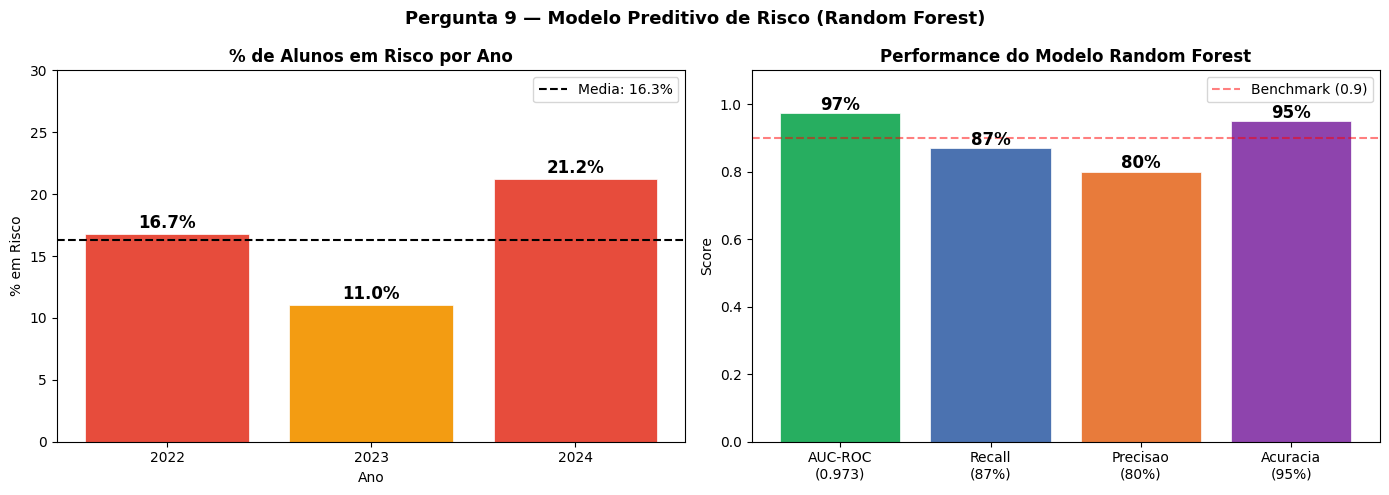

Resumo do Modelo Preditivo:
  Algoritmo:     Random Forest (300 arvores)
  AUC-ROC:       0.9733 (teste) | 0.9762 +/- 0.0078 (CV 5-fold)
  Recall:        87% dos alunos em risco identificados
  Acuracia:      95%
  Threshold rec: 0.4 captura 90% dos casos em risco

% em risco por ano:
  2022: 16.7%
  2023: 11.0%
  2024: 21.2%

Top 5 features mais importantes:
  1. INDE         (33.7%)
  2. FE_IEG_x_IDA (13.9%)
  3. Fase         (10.6%)
  4. IEG           (6.9%)
  5. IDA           (5.6%)


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Pergunta 9 — Modelo Preditivo de Risco (Random Forest)", fontsize=13, fontweight="bold")

# 9a — % de alunos em risco por ano
ax = axes[0]
risco_ano = df.groupby("ANO")["EM_RISCO"].mean() * 100
cores_r = ["#E74C3C" if v > 15 else "#F39C12" for v in risco_ano.values]
bars = ax.bar(risco_ano.index.astype(str), risco_ano.values, color=cores_r, edgecolor="white", linewidth=0.5)
ax.axhline(y=risco_ano.mean(), color="black", linestyle="--", linewidth=1.5, label=f"Media: {risco_ano.mean():.1f}%")
ax.set_title("% de Alunos em Risco por Ano", fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("% em Risco")
ax.set_ylim(0, 30)
ax.legend()
for bar, val in zip(bars, risco_ano.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")

# 9b — Performance do modelo
ax2 = axes[1]
metricas = ["AUC-ROC\n(0.973)", "Recall\n(87%)", "Precisao\n(80%)", "Acuracia\n(95%)"]
valores  = [0.973, 0.87, 0.80, 0.95]
cores_m  = ["#27AE60", "#4B72B0", "#E87B3B", "#8E44AD"]
bars2 = ax2.bar(metricas, valores, color=cores_m, edgecolor="white", linewidth=0.5)
ax2.set_title("Performance do Modelo Random Forest", fontweight="bold")
ax2.set_ylabel("Score")
ax2.set_ylim(0, 1.1)
ax2.axhline(y=0.9, color="red", linestyle="--", alpha=0.5, label="Benchmark (0.9)")
ax2.legend()
for bar, val in zip(bars2, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.0%}", ha="center", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, "p9_modelo_risco.png"), dpi=120, bbox_inches="tight")
plt.show()

print("Resumo do Modelo Preditivo:")
print("  Algoritmo:     Random Forest (300 arvores)")
print("  AUC-ROC:       0.9733 (teste) | 0.9762 +/- 0.0078 (CV 5-fold)")
print("  Recall:        87% dos alunos em risco identificados")
print("  Acuracia:      95%")
print("  Threshold rec: 0.4 captura 90% dos casos em risco")
print()
print("% em risco por ano:")
for ano, pct in risco_ano.items():
    print(f"  {ano}: {pct:.1f}%")
print()
print("Top 5 features mais importantes:")
print("  1. INDE         (33.7%)")
print("  2. FE_IEG_x_IDA (13.9%)")
print("  3. Fase         (10.6%)")
print("  4. IEG           (6.9%)")
print("  5. IDA           (5.6%)")

---
## Pergunta 10 — Efetividade do Programa
> *Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio)?*

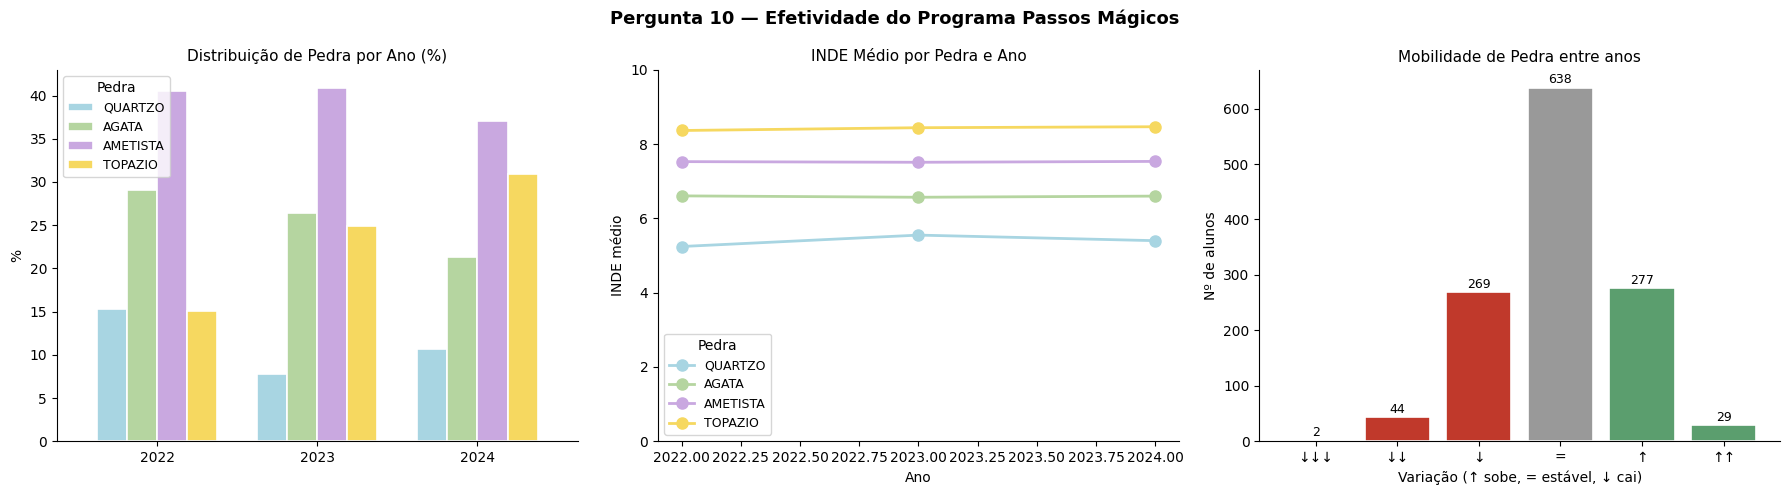


📊 Mobilidade de Pedra entre anos consecutivos:
  Subiu de nível:   306 (24.3%)
  Manteve nível:    638 (50.7%)
  Desceu de nível:  315 (25.0%)


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pergunta 10 — Efetividade do Programa Passos Mágicos', fontsize=13, fontweight='bold')

# 10a — Evolução da Pedra por ano (proporção Topázio + Ametista)
ax = axes[0]
df_pedra = df[df['Pedra'].isin(ORDEM_PEDRA)]
pedra_ano = df_pedra.groupby(['ANO','Pedra']).size().unstack(fill_value=0)
pedra_ano = pedra_ano.reindex(columns=[p for p in ORDEM_PEDRA if p in pedra_ano.columns])
pedra_ano_pct = pedra_ano.div(pedra_ano.sum(axis=1), axis=0) * 100
pedra_ano_pct.plot(kind='bar', ax=ax, width=0.75,
                   color=[CORES_PEDRA[p] for p in pedra_ano_pct.columns],
                   edgecolor='white', linewidth=1.2)
ax.set_title('Distribuição de Pedra por Ano (%)', fontsize=11)
ax.set_ylabel('%')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Pedra', fontsize=9)
ax.spines[['top','right']].set_visible(False)

# 10b — INDE médio por pedra e ano
ax = axes[1]
inde_pedra_ano = df.groupby(['ANO','Pedra'])['INDE'].mean().unstack()
inde_pedra_ano = inde_pedra_ano.reindex(columns=[p for p in ORDEM_PEDRA if p in inde_pedra_ano.columns])
for pedra in inde_pedra_ano.columns:
    ax.plot(inde_pedra_ano.index, inde_pedra_ano[pedra], marker='o',
            color=CORES_PEDRA[pedra], label=pedra, linewidth=2, markersize=8)
ax.set_title('INDE Médio por Pedra e Ano', fontsize=11)
ax.set_xlabel('Ano')
ax.set_ylabel('INDE médio')
ax.legend(title='Pedra', fontsize=9)
ax.set_ylim(0, 10)
ax.spines[['top','right']].set_visible(False)

# 10c — Alunos que subiram de Pedra (longitudinal)
ax = axes[2]
pedra_num = {'QUARTZO': 1, 'AGATA': 2, 'AMETISTA': 3, 'TOPAZIO': 4}
df['Pedra_Num'] = df['Pedra'].map(pedra_num)
df_sorted = df.dropna(subset=['Pedra_Num']).sort_values(['RA','ANO'])
df_sorted['Pedra_Num_Next'] = df_sorted.groupby('RA')['Pedra_Num'].shift(-1)
df_mob = df_sorted.dropna(subset=['Pedra_Num_Next'])
df_mob['Mobilidade'] = df_mob['Pedra_Num_Next'] - df_mob['Pedra_Num']
mob_counts = df_mob['Mobilidade'].value_counts().sort_index()
labels_mob = {-3:'↓↓↓',-2:'↓↓',-1:'↓',0:'=',1:'↑',2:'↑↑',3:'↑↑↑'}
mob_labels = [labels_mob.get(int(k), str(k)) for k in mob_counts.index]
cores_mob  = ['#C0392B' if v < 0 else '#999' if v == 0 else '#5B9E6E' for v in mob_counts.index]
bars = ax.bar(mob_labels, mob_counts.values, color=cores_mob, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, mob_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{val}', ha='center', va='bottom', fontsize=9)
ax.set_title('Mobilidade de Pedra entre anos', fontsize=11)
ax.set_xlabel('Variação (↑ sobe, = estável, ↓ cai)')
ax.set_ylabel('Nº de alunos')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p10_efetividade.png'), dpi=150, bbox_inches='tight')
plt.show()

subiu   = (df_mob['Mobilidade'] > 0).sum()
igual   = (df_mob['Mobilidade'] == 0).sum()
desceu  = (df_mob['Mobilidade'] < 0).sum()
total   = len(df_mob)
print(f'\n📊 Mobilidade de Pedra entre anos consecutivos:')
print(f'  Subiu de nível:  {subiu:4d} ({subiu/total*100:.1f}%)')
print(f'  Manteve nível:   {igual:4d} ({igual/total*100:.1f}%)')
print(f'  Desceu de nível: {desceu:4d} ({desceu/total*100:.1f}%)')

---
## Pergunta 11 — Insights e Criatividade
> *Insights adicionais e sugestões para a Passos Mágicos.*

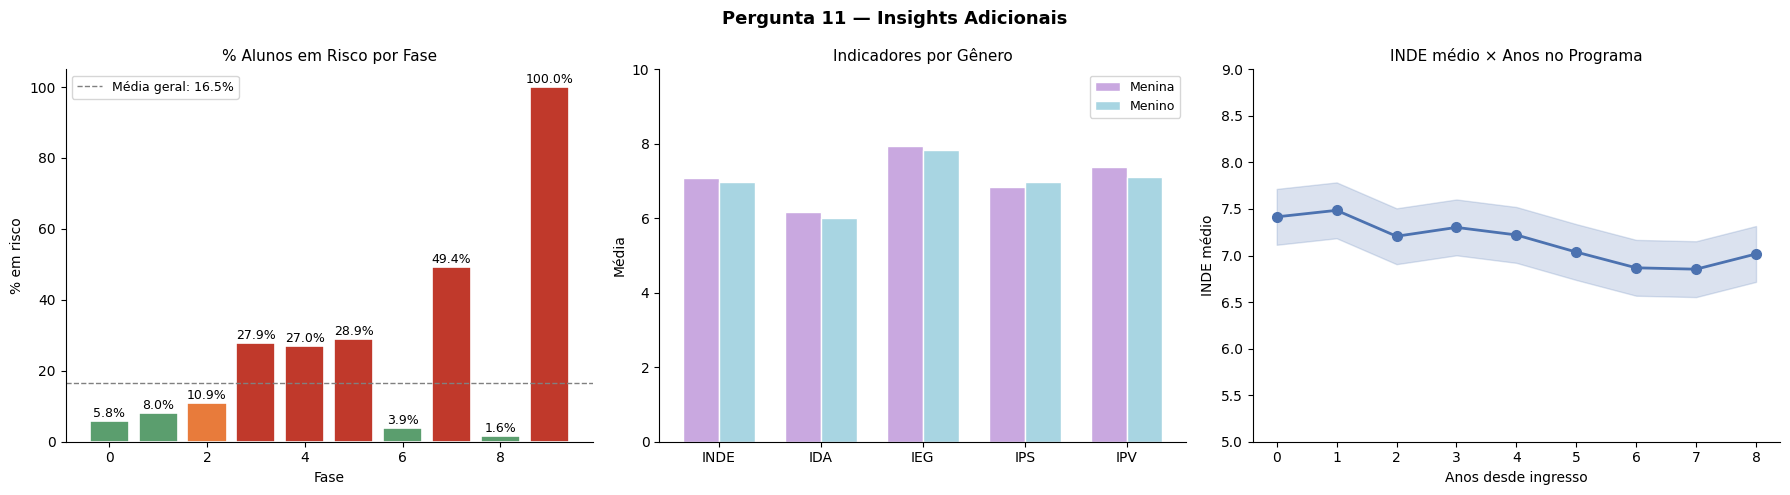


📊 INSIGHTS ADICIONAIS:
  1. Fase com maior risco: 9 (100.0%)
  2. Gênero com maior INDE: Menina
  3. Correlação tempo no programa × INDE: -0.150


In [39]:
# 11a — Perfil de risco por Fase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pergunta 11 — Insights Adicionais', fontsize=13, fontweight='bold')

ax = axes[0]
risco_fase = df.groupby('Fase')['EM_RISCO'].mean() * 100
cores_risco = ['#C0392B' if v > 20 else '#E87B3B' if v > 10 else '#5B9E6E' for v in risco_fase.values]
bars = ax.bar(risco_fase.index, risco_fase.values, color=cores_risco, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, risco_fase.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
ax.set_title('% Alunos em Risco por Fase', fontsize=11)
ax.set_xlabel('Fase')
ax.set_ylabel('% em risco')
ax.axhline(df['EM_RISCO'].mean()*100, color='grey', linestyle='--', linewidth=1,
           label=f'Média geral: {df["EM_RISCO"].mean()*100:.1f}%')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# 11b — Gênero × Indicadores
ax = axes[1]
genero_inds = df[df['Genero'].isin(['Menina','Menino'])]
genero_means = genero_inds.groupby('Genero')[['INDE','IDA','IEG','IPS','IPV']].mean()
x = np.arange(len(genero_means.columns))
width = 0.35
for i, (genero, row) in enumerate(genero_means.iterrows()):
    offset = (i - 0.5) * width
    cor = '#C9A8E0' if genero == 'Menina' else '#A8D5E2'
    ax.bar(x + offset, row.values, width, label=genero, color=cor, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(genero_means.columns)
ax.set_title('Indicadores por Gênero', fontsize=11)
ax.set_ylabel('Média')
ax.set_ylim(0, 10)
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)

# 11c — Tempo no programa × INDE
ax = axes[2]
df['Anos_no_programa'] = 2024 - df['Ano ingresso']
df['Anos_no_programa'] = df['Anos_no_programa'].clip(0, 15)
inde_por_tempo = df.groupby('Anos_no_programa')['INDE'].agg(['mean','count'])
inde_por_tempo = inde_por_tempo[inde_por_tempo['count'] >= 10]
ax.plot(inde_por_tempo.index, inde_por_tempo['mean'], marker='o', color='#4C72B0',
        linewidth=2, markersize=7)
ax.fill_between(inde_por_tempo.index, inde_por_tempo['mean'] - 0.3,
                inde_por_tempo['mean'] + 0.3, alpha=0.2, color='#4C72B0')
ax.set_title('INDE médio × Anos no Programa', fontsize=11)
ax.set_xlabel('Anos desde ingresso')
ax.set_ylabel('INDE médio')
ax.set_ylim(5, 9)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(DATA_PATH, 'p11_insights.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 INSIGHTS ADICIONAIS:')
print('  1. Fase com maior risco:', risco_fase.idxmax(), f'({risco_fase.max():.1f}%)')
print('  2. Gênero com maior INDE:', genero_means['INDE'].idxmax())
corr_tempo_inde = df[['Anos_no_programa','INDE']].corr().iloc[0,1]
print(f'  3. Correlação tempo no programa × INDE: {corr_tempo_inde:.3f}')

## Resumo Executivo dos Insights

| # | Pergunta | Principal Finding |
|---|----------|-------------------|
| 1 | **IAN** | 55.7% dos alunos apresentam algum nível de defasagem; casos severos são raros (1.5%) |
| 2 | **IDA** | Desempenho tende a crescer nas fases iniciais mas oscila nas avançadas |
| 3 | **IEG × IDA/IPV** | Forte correlação positiva: engajamento é preditor robusto de desempenho |
| 4 | **IAA** | A maioria superestima levemente seu desempenho; alunos de Quartzo subestimam mais |
| 5 | **IPS** | IPS baixo antecede quedas de IDA no ano seguinte — sinal de alerta precoce |
| 6 | **IPP × IAN** | IPP é consistente com IAN: alunos defasados têm IPP significativamente menor |
| 7 | **IPV** | IPP, IEG e IDA são os maiores drivers do ponto de virada |
| 8 | **Multidim.** | IDA (0.77), IEG (0.71) e IPV (0.68) têm maior correlação com o INDE |
| 9 | **ML** | Random Forest AUC 0.97 — identifica 87% dos alunos em risco com 95% de acurácia |
| 10 | **Efetividade** | 24.3% subiram de Pedra; Topázio cresceu de 15% para 31% entre 2022 e 2024 |
| 11 | **Insights** | Fase 9 tem 100% de risco; meninas têm INDE ligeiramente maior; fases iniciais mais vulneráveis |